In [1]:
from analytical import *
from electronic import *
from engine import *
from integrator import *
from selector import *
from trajectory import *
from path_sampling import *
import numpy as np
from matplotlib import pyplot as plt
import pickle

In [2]:
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue  = "#1B3F6B"

palette = [winter_pine, cranberry, golden, oxford_blue]

In [4]:
# Load data for coupling
# Unless you have a computer that is as cool as mine, loading everything here will blow up your memory.

Vcx10 = [1,2,3,4,5,6,7,8]

grand_list_V = []
for coupling in Vcx10:
    with open(f'data/TPS_data_Vc{coupling}.pkl', 'rb') as f:
        obj = pickle.load(f)
        grand_list_V.append(obj)

tps_ensemble_list = [grand_list_V[i]['tps_ensemble'] for i in range(len(grand_list_V))]
naive_tps_ensemble_list = [grand_list_V[i]['naive_ensemble'] for i in range(len(grand_list_V))]
MC_rate_list = [grand_list_V[i]['MC rate'] for i in range(len(grand_list_V))]
TT_dist_list = [grand_list_V[i]['Transition time'] for i in range(len(grand_list_V))]
q_hop_dist_list = [grand_list_V[i]['hopping geometries'] for i in range(len(grand_list_V))]
autocorr_list = [grand_list_V[i]['Autocorrelation'] for i in range(len(grand_list_V))]
processor = PathSampling(selector=None, seed_traj=None, max_iter=None, max_length=None, in_stateA=None, in_stateB=None)
TTS = [processor.hop_statistics(ensemble) for ensemble in tps_ensemble_list]
mean_hop_list = [TTS[i][0] for i in range(len(TTS))]
mean_hop_std = [TTS[i][1] for i in range(len(TTS))]
mtt_list = [np.mean(TT_dist_list[i]) for i in range(len(TT_dist_list))]
mtt_std_list = [np.std(TT_dist_list[i]) for i in range(len(TT_dist_list))]

total number of hops: 9886
Mean Number of Hops: 1.163
Standard Deviation of Hops: 1.301
total number of hops: 5208
Mean Number of Hops: 0.613
Standard Deviation of Hops: 1.167
total number of hops: 3794
Mean Number of Hops: 0.446
Standard Deviation of Hops: 1.228
total number of hops: 1836
Mean Number of Hops: 0.216
Standard Deviation of Hops: 0.970
total number of hops: 1374
Mean Number of Hops: 0.162
Standard Deviation of Hops: 0.936
total number of hops: 1376
Mean Number of Hops: 0.162
Standard Deviation of Hops: 1.110
total number of hops: 778
Mean Number of Hops: 0.092
Standard Deviation of Hops: 0.479
total number of hops: 492
Mean Number of Hops: 0.058
Standard Deviation of Hops: 0.660


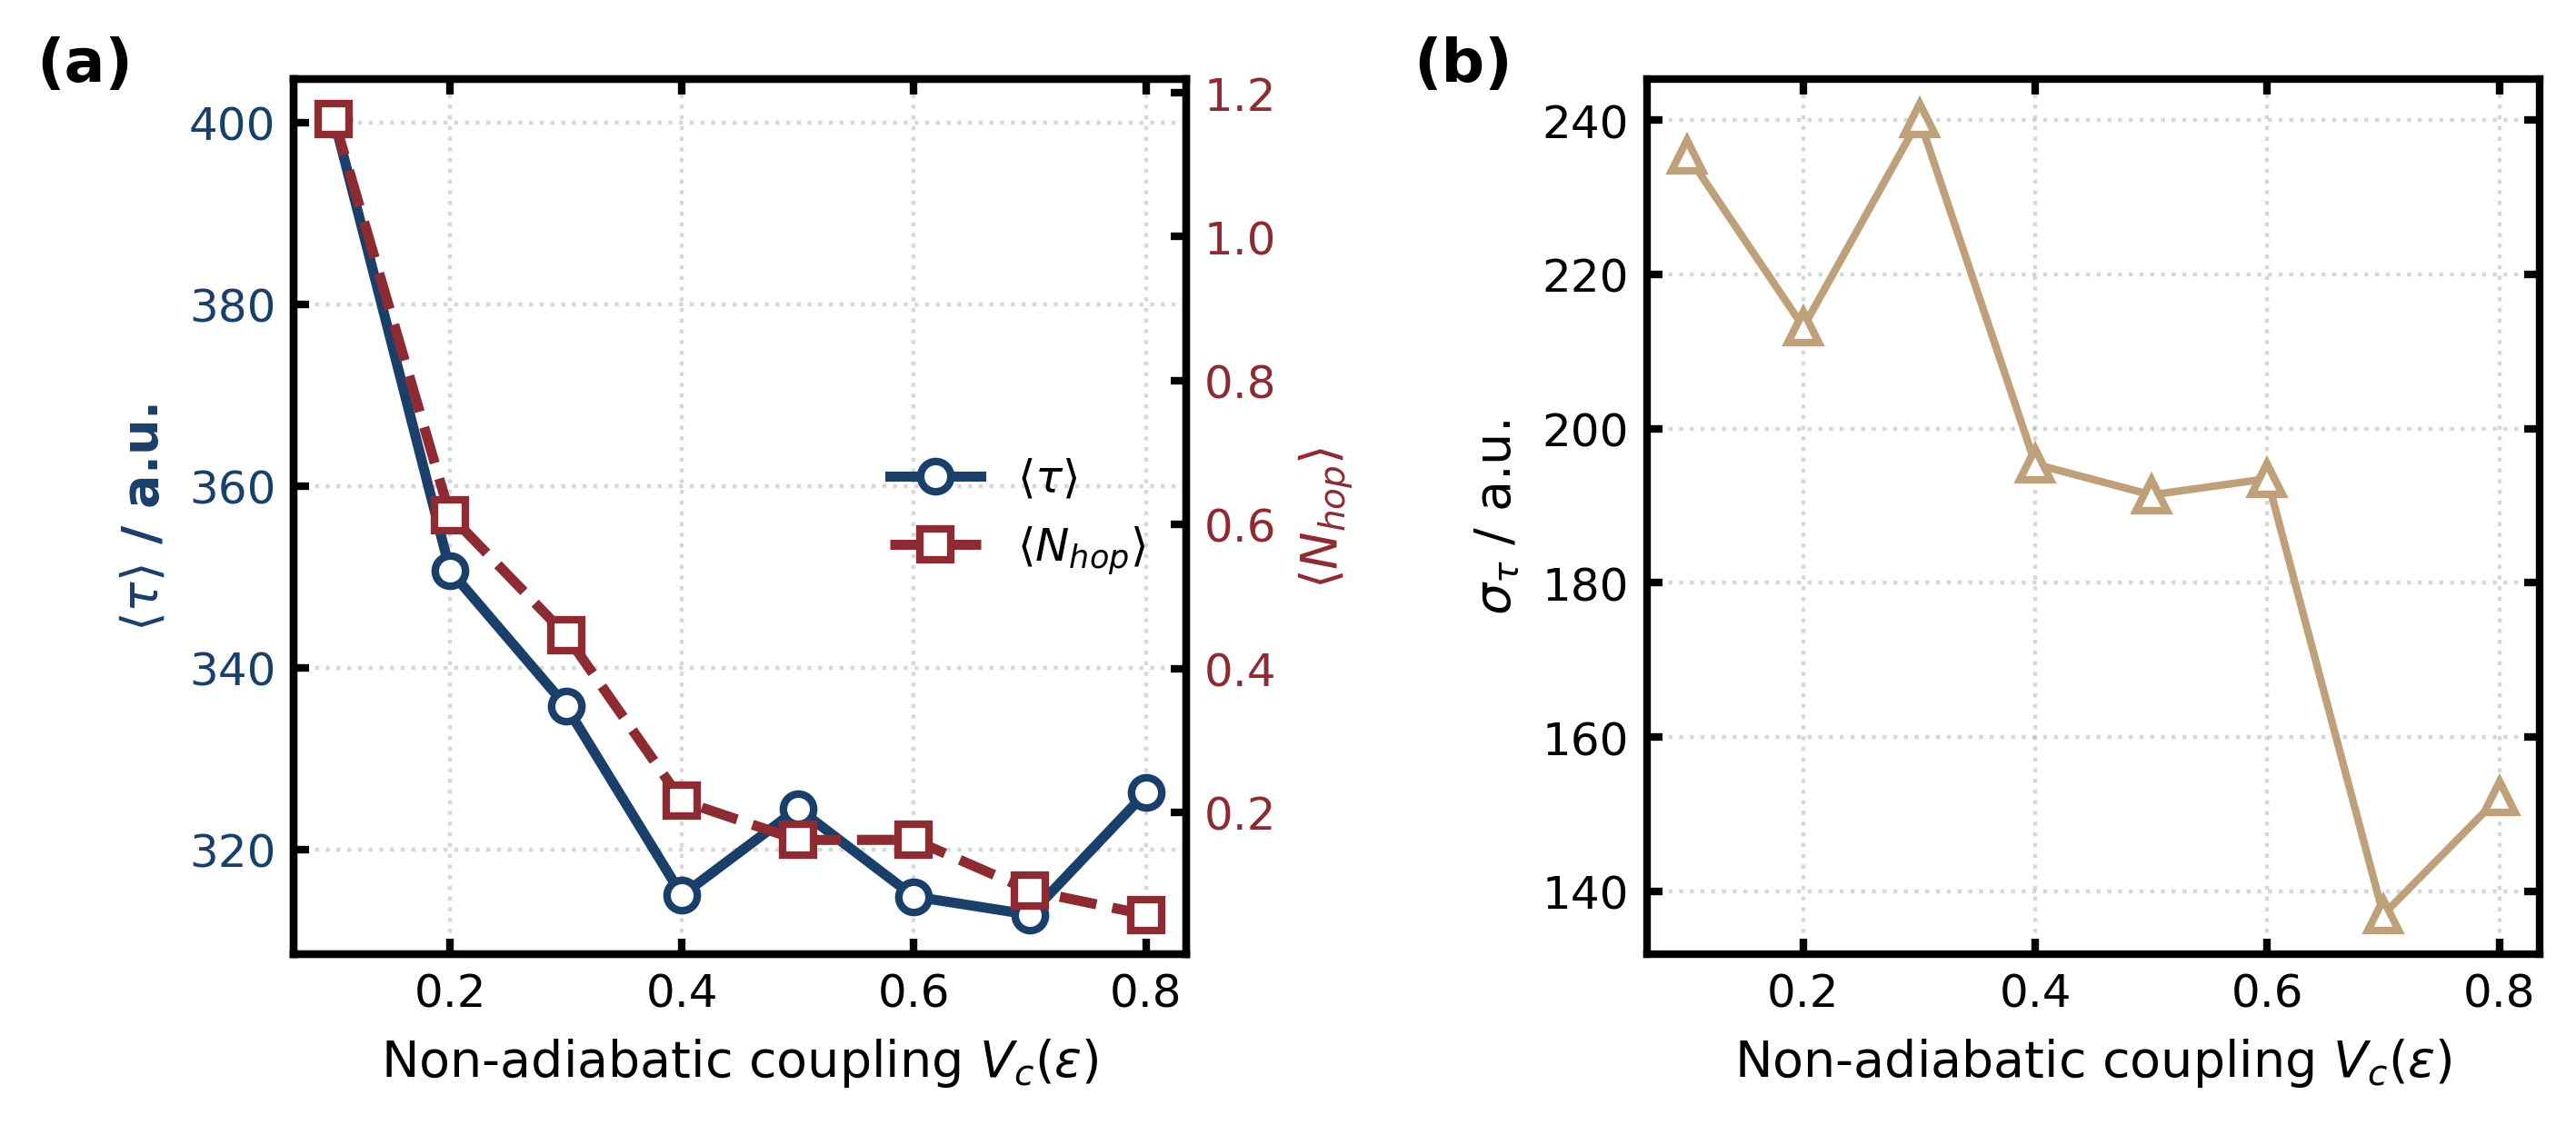

In [6]:
import matplotlib.pyplot as plt
import numpy as np

Vc = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def plot_combined_kinetics_publish(temperature_sweep, mtt_list, mean_hop_list, mtt_std_list):
    # ==========================================
    # 1. Aesthetic Setup (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Sort the arrays to guarantee strict left-to-right line drawing
    temps = np.array(temperature_sweep)
    sort_idx = np.argsort(temps)
    temps = temps[sort_idx]
    mtts = np.array(mtt_list)[sort_idx]
    hops = np.array(mean_hop_list)[sort_idx]
    stds = np.array(mtt_std_list)[sort_idx]

    # Create a 1x2 double-column figure (7.2 inches wide)
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), dpi=400)

    # ==========================================
    # PANEL (a): MTT & MNT Overlay
    # ==========================================
    ax1 = axes[0]
    
    # Left Axis: MTT
    ax1.set_xlabel(r"Non-adiabatic coupling $V_c$($\epsilon$)", fontweight='medium')
    ax1.set_ylabel(r'$\langle \tau \rangle$ / a.u.', color=oxford_blue, fontweight='bold')
    
    line1 = ax1.plot(temps, mtts, color=oxford_blue, linewidth=2, 
                     linestyle='-', marker='o', markersize=6, markerfacecolor='white', 
                     markeredgewidth=1.5, zorder=3, label=r'$\langle \tau \rangle$')
    
    ax1.tick_params(axis='y', labelcolor=oxford_blue, direction='in')
    ax1.tick_params(axis='x', direction='in', top=True)
    ax1.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Right Axis: MNT
    ax2 = ax1.twinx()
    ax2.set_ylabel(r'$\langle N_{hop} \rangle$', color=cranberry, fontweight='bold')
    
    line2 = ax2.plot(temps, hops, color=cranberry, linewidth=2, 
                     linestyle='--', marker='s', markersize=6, markerfacecolor='white', 
                     markeredgewidth=1.5, zorder=4, label=r'$\langle N_{hop} \rangle$')
    
    ax2.tick_params(axis='y', labelcolor=cranberry, direction='in')

    # Combine legends into a minimalist box
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right', frameon=False, fontsize=9)

    # Ensure right spine is thick for ax2
    for spine in ax2.spines.values():
        spine.set_linewidth(1.5)

    # ==========================================
    # PANEL (b): Standard Deviation
    # ==========================================
    ax3 = axes[1]
    
    ax3.plot(temps, stds, color=golden, linewidth=1.5, linestyle='-', 
             marker='^', markersize=6, markerfacecolor='white', 
             markeredgewidth=1.5, zorder=3)

    ax3.set_xlabel(r"Non-adiabatic coupling $V_c$($\epsilon$)", fontweight='medium')
    ax3.set_ylabel(r"$\sigma_\tau$ / a.u.", fontweight='medium')
    
    ax3.tick_params(direction='in', top=True, right=True)
    ax3.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # ==========================================
    # FINAL POLISH & EXPORT
    # ==========================================
    # Add publication-style panel letters
    ax1.text(-0.18, 1.05, '(a)', transform=ax1.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
    ax3.text(-0.15, 1.05, '(b)', transform=ax3.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')

    plt.tight_layout()
    plt.savefig("Combined_Kinetic_Statistics.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run the plot:
plot_combined_kinetics_publish(Vc, mtt_list, mean_hop_list, mtt_std_list)

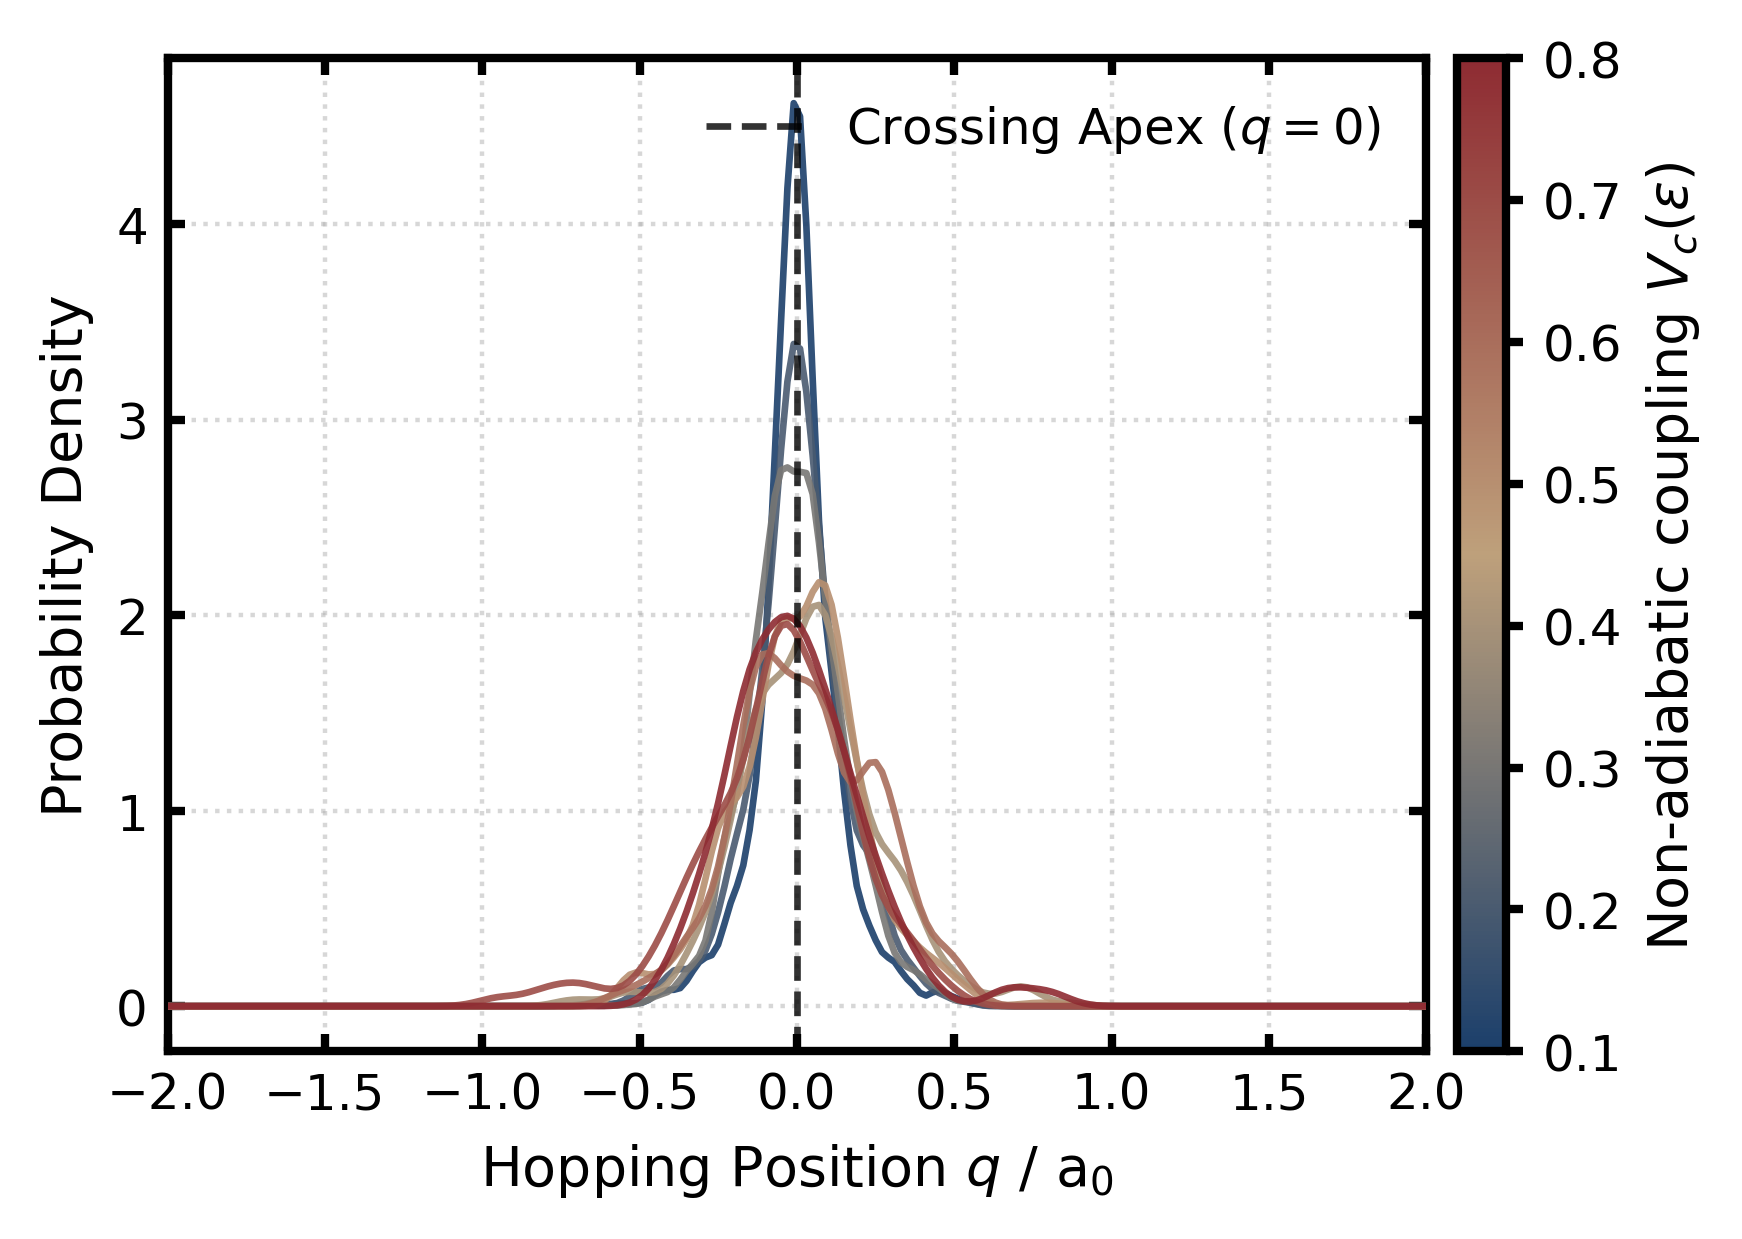

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def plot_hopping_geometry_kde_publish(temperature_sweep, q_hop_dist_list, min_hops=50):
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # A slightly wider format (4.5 x 3.2) accommodates the colorbar perfectly 
    # without shrinking the central plot area too much.
    fig, ax = plt.subplots(figsize=(4.5, 3.2), dpi=400)
    
    # Create the bespoke journal colormap: Blue (Cold) -> Gold (Mid) -> Cranberry (Hot)
    custom_cmap = mcolors.LinearSegmentedColormap.from_list(
        "custom_temp", [oxford_blue, golden, cranberry]
    )
    norm = mcolors.Normalize(vmin=min(temperature_sweep), vmax=max(temperature_sweep))
    
    q_eval = np.linspace(-5, 5, 500) 
    plotted_any = False
    
    # ==========================================
    # 2. PLOTTING THE DISTRIBUTIONS
    # ==========================================
    for temp, q_hops in zip(temperature_sweep, q_hop_dist_list):
        q_hops = np.array(q_hops)
        
        if len(q_hops) < min_hops:
            continue
            
        try:
            kde = gaussian_kde(q_hops, bw_method='scott') 
            density = kde(q_eval)
        except np.linalg.LinAlgError:
            continue
            
        color = custom_cmap(norm(temp))
        
        # Thinner lines for print resolution (1.5 instead of 2.5)
        ax.plot(q_eval, density, color=color, linewidth=1.2, alpha=0.9, zorder=3)
        plotted_any = True
        
    if not plotted_any:
        print("Error: No ensembles met the min_hops criteria.")
        return
        
    # ==========================================
    # 3. LABELS, LEGEND & COLORBAR
    # ==========================================
    # Add a continuous colorbar 
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r"Non-adiabatic coupling $V_c$($\epsilon$)", fontweight='medium')
    cbar.outline.set_linewidth(1.5) # Match colorbar border to axes
    
    # Crossing apex indicator
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.2, alpha=0.8, 
               zorder=4, label='Crossing Apex ($q=0$)')
    
    # Journal-standard axis labels
    ax.set_xlabel("Hopping Position $q$ / a$_0$", fontweight='medium')
    ax.set_ylabel("Probability Density", fontweight='medium')
    ax.set_xlim([-2, 2])
    
    # Elegant grid and ticks
    ax.grid(True, linestyle=':', alpha=0.5, zorder=1)
    ax.tick_params(direction='in', top=True, right=True)
    
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Clean legend without bounding box
    ax.legend(loc='upper right', fontsize=9, frameon=False)
    
    plt.tight_layout()
    plt.savefig("Hopping_Geometry_KDE.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run it:
plot_hopping_geometry_kde_publish(Vc, q_hop_dist_list)